# Quantum VQC Classifier

Binary classification on the Iris dataset using a Variational Quantum Classifier (VQC)
built with `qiskit-machine-learning`.

This notebook trains the quantum model and saves results to `vqc_results.json`  
for later use in `comparison/comparison.ipynb`.

**How a VQC works (briefly):**  
A VQC is a parameterized quantum circuit split into two parts:
1. **Feature map**: encodes classical input data into quantum states (angles of rotation gates).
2. **Ansatz**: a trainable circuit whose gate angles are optimized during training.

The output is the probability of measuring a certain qubit state, which is mapped to a class label.
Training adjusts the ansatz parameters to minimize a loss function, exactly like gradient descent
in a classical neural network.

**Configuration variable:** `N_FEATURES` controls how many features (and qubits) are used.  
For the 4-feature version, set `N_FEATURES = 4` and results save to `vqc_results_4f.json`.

**Hardware:** Training runs on the Aer simulator. Set `RUN_ON_REAL_HW = True` to evaluate
the trained model on IBM Quantum hardware (requires a valid IBM account configured).

## Imports

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.primitives import SamplerV2 as AerSampler

from qiskit_machine_learning.optimizers import SPSA, L_BFGS_B
from qiskit_machine_learning.algorithms import VQC

## Configuration

In [2]:
N_FEATURES      = 2          # 2 or 4 — must match svm.ipynb
TEST_SIZE       = 0.2        # must match svm.ipynb
RANDOM_SEED     = 42         # must match svm.ipynb
MAX_ITER        = 300        # optimizer iterations
N_RUNS          = 3          # independent runs with different initial points
INIT_SEEDS      = [42, 123, 7]  # random seeds for ansatz initialization
RUN_ON_REAL_HW  = False      # set True to evaluate on IBM Quantum after training
OPTIMIZER_NAME  = "SPSA"     # "SPSA" or "L_BFGS_B"

_suffix_f   = "" if N_FEATURES == 2 else "_4f"
_suffix_opt = "" if OPTIMIZER_NAME == "SPSA" else f"_{OPTIMIZER_NAME.lower()}"
FILE_SUFFIX  = f"{_suffix_f}{_suffix_opt}"
RESULTS_FILE = f"vqc_results{FILE_SUFFIX}.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, MAX_ITER={MAX_ITER}, N_RUNS={N_RUNS}, OPTIMIZER={OPTIMIZER_NAME}, RUN_ON_REAL_HW={RUN_ON_REAL_HW}")
print(f"Results will be saved to: {RESULTS_FILE}")


Configuration: N_FEATURES=2, MAX_ITER=300, N_RUNS=3, OPTIMIZER=SPSA, RUN_ON_REAL_HW=False
Results will be saved to: vqc_results.json


## Dataset

Identical preprocessing to `svm.ipynb` — same seed, same split, same scaling.
Both models must receive the exact same train/test data for a fair comparison.

**Nota sobre el escalado:** El SVM recibe los datos en `[0, 1]` (MinMaxScaler estándar).
El VQC aplica adicionalmente un factor `× π`, dejando las features en `[0, π]`.
Esto es estándar en VQCs: las puertas de rotación del feature map tienen período `2π`,
por lo que escalar hasta `π` aprovecha la mitad del rango angular sin ambigüedad de fase.
No introduce sesgo comparativo porque ambos modelos ven la misma estructura relativa de los datos.


In [3]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1      # remap to {0, 1}

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Scale to [0, π] so features span the full range of rotation gates
X_scaled_pi = X_scaled * np.pi

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_pi, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled_pi)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features used : {feature_names}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features used : ['petal length', 'petal width']


## Quantum Algorithm — VQC

### Circuit architecture

**Feature map — `ZZFeatureMap`**  
Encodes each input vector into a quantum state using rotation gates (Ry, Rz) and
entangling ZZ interactions. With `reps=2`, the encoding applies twice, increasing
expressiveness. The number of qubits equals `N_FEATURES`.

**Ansatz — `RealAmplitudes`**  
A hardware-efficient variational circuit with Ry rotations and CNOT entangling layers.
With `reps=3`, the circuit has enough parameters to represent complex decision boundaries.
These are the trainable parameters.

**Optimizer — SPSA (Simultaneous Perturbation Stochastic Approximation)**  
A stochastic gradient-free optimizer designed for noisy landscapes. Unlike COBYLA,
which builds a quadratic model of the objective and stops early when the model is flat,
SPSA estimates the gradient via random simultaneous perturbations and runs for the full
`MAX_ITER` iterations. It is the standard choice for variational quantum circuits because
their loss landscapes are non-convex and noisy — exactly the conditions where COBYLA
gets stuck in bad local minima.


Number of qubits         : 2
Feature map depth (reps) : 2
Ansatz depth (reps)      : 3
Trainable parameters     : 8

--- Feature Map ---


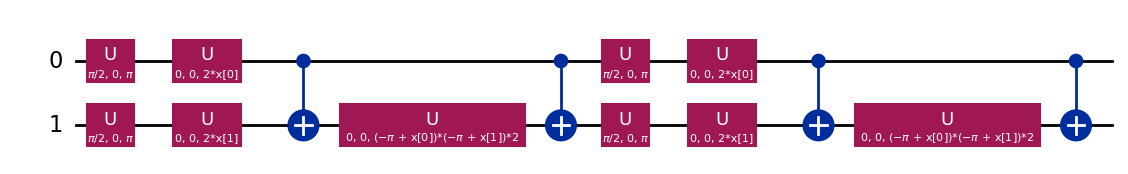


--- Ansatz ---


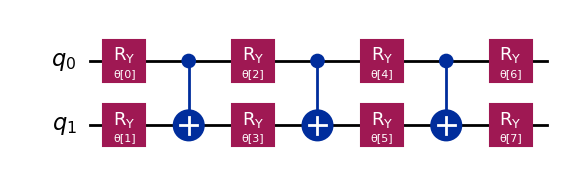

In [4]:
n_qubits    = N_FEATURES
feature_map = zz_feature_map(feature_dimension=n_qubits, reps=2)
ansatz      = real_amplitudes(num_qubits=n_qubits, reps=3)

print(f"Number of qubits         : {n_qubits}")
print(f"Feature map depth (reps) : 2")
print(f"Ansatz depth (reps)      : 3")
print(f"Trainable parameters     : {ansatz.num_parameters}")

print("\n--- Feature Map ---")
display(feature_map.decompose().draw(output="mpl", fold=-1))

print("\n--- Ansatz ---")
display(ansatz.draw(output="mpl", fold=-1))

## Training on Aer Simulator

In [5]:
# ── Single reference run (seed INIT_SEEDS[0]) ──────────────────────────────
# NOTE: TrainableModel.__init__ overwrites optimizer.callback with the VQC-level callback,
# so the callback must be passed to VQC (not to SPSA). For SPSA, it is called with 5 args:
# (nfev, x, fx, dx, is_final) — different from the 2-arg VQC callback for SciPy optimizers.
loss_history = []

backend      = AerSimulator()
pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=1)

# L_BFGS_B uses parameter-shift gradients internally; passing pass_manager causes
# a layout bug in ParamShiftSamplerGradient (circuit.layout is None after transpile).
_pm = pass_manager if OPTIMIZER_NAME == "SPSA" else None

rng_ref       = np.random.default_rng(INIT_SEEDS[0])
initial_point = rng_ref.uniform(0, 2 * np.pi, size=ansatz.num_parameters)

if OPTIMIZER_NAME == "SPSA":
    ref_optimizer = SPSA(maxiter=MAX_ITER)

    def _ref_cb(nfev, x, fx, dx, is_final):
        loss_history.append(float(fx))
        if nfev % 30 == 0:
            print(f"  nfev {nfev:>4} | Loss: {fx:.4f}")

    vqc_callback = _ref_cb
else:
    ref_optimizer = L_BFGS_B(maxiter=MAX_ITER)
    vqc_callback  = None

vqc = VQC(
    sampler       = AerSampler(),
    feature_map   = deepcopy(feature_map),
    ansatz        = deepcopy(ansatz),
    optimizer     = ref_optimizer,
    pass_manager  = _pm,
    initial_point = initial_point,
    callback      = vqc_callback,
)

print(f"Training VQC — reference run (seed={INIT_SEEDS[0]}, {MAX_ITER} max iter, {OPTIMIZER_NAME})...")
t0 = time.perf_counter()
vqc.fit(X_train, y_train)
train_time_sim = time.perf_counter() - t0

print(f"\nReference run completed in {train_time_sim:.2f} s")
if loss_history:
    print(f"Final loss: {loss_history[-1]:.4f}")
else:
    print(f"(Loss history not recorded for {OPTIMIZER_NAME})")

# ── Multi-seed stability runs ─────────────────────────────────────────────────
print(f"\nRunning {N_RUNS} independent runs with seeds {INIT_SEEDS}...")
run_records = []

for seed in INIT_SEEDS:
    rng  = np.random.default_rng(seed)
    ip   = rng.uniform(0, 2 * np.pi, size=ansatz.num_parameters)
    r_loss = []

    if OPTIMIZER_NAME == "SPSA":
        run_opt     = SPSA(maxiter=MAX_ITER)
        run_cb      = lambda nfev, x, fx, dx, fin, _l=r_loss: _l.append(float(fx))
        run_vqc_cb  = run_cb
    else:
        run_opt    = L_BFGS_B(maxiter=MAX_ITER)
        run_vqc_cb = None

    vqc_r = VQC(
        sampler       = AerSampler(),
        feature_map   = deepcopy(feature_map),
        ansatz        = deepcopy(ansatz),
        optimizer     = run_opt,
        pass_manager  = _pm,
        initial_point = ip,
        callback      = run_vqc_cb,
    )

    t0 = time.perf_counter()
    vqc_r.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    acc_test  = accuracy_score(y_test,  vqc_r.predict(X_test))
    acc_train = accuracy_score(y_train, vqc_r.predict(X_train))
    final_loss = r_loss[-1] if r_loss else None
    run_records.append({
        "seed": seed, "acc_test": acc_test, "acc_train": acc_train,
        "time": elapsed, "final_loss": final_loss,
        "loss_history": r_loss,
    })
    loss_str = f"{final_loss:.4f}" if final_loss is not None else "N/A"
    print(f"  seed={seed:>3} | test={acc_test:.4f}  train={acc_train:.4f}  "
          f"loss={loss_str}  time={elapsed:.1f}s")

acc_test_runs  = [r["acc_test"]  for r in run_records]
acc_train_runs = [r["acc_train"] for r in run_records]
acc_test_mean  = float(np.mean(acc_test_runs))
acc_test_std   = float(np.std(acc_test_runs))
acc_train_mean = float(np.mean(acc_train_runs))
acc_train_std  = float(np.std(acc_train_runs))

print(f"\nMulti-seed summary ({N_RUNS} runs):")
print(f"  Test  accuracy : {acc_test_mean:.4f} ± {acc_test_std:.4f}")
print(f"  Train accuracy : {acc_train_mean:.4f} ± {acc_train_std:.4f}")


Training VQC — reference run (seed=42, 300 max iter, SPSA)...


  nfev   30 | Loss: 0.8821


  nfev   60 | Loss: 0.8797


  nfev   90 | Loss: 0.8690


  nfev  120 | Loss: 0.8588


...

  nfev  870 | Loss: 0.7348


  nfev  900 | Loss: 0.7364

Reference run completed in 219.35 s
Final loss: 0.7364

Running 3 independent runs with seeds [42, 123, 7]...


  seed= 42 | test=0.7000  train=0.7500  loss=0.7383  time=216.7s


  seed=123 | test=0.5000  train=0.6500  loss=0.8756  time=212.0s


  seed=  7 | test=0.7000  train=0.7625  loss=0.7397  time=216.7s

Multi-seed summary (3 runs):
  Test  accuracy : 0.6333 ± 0.0943
  Train accuracy : 0.7208 ± 0.0503


## Evaluation on Simulator

In [6]:
y_pred_train_sim = vqc.predict(X_train)
y_pred_test_sim  = vqc.predict(X_test)

acc_train_sim = accuracy_score(y_train, y_pred_train_sim)
acc_test_sim  = accuracy_score(y_test,  y_pred_test_sim)

print("Reference run (single seed):")
print(f"  Train accuracy : {acc_train_sim:.4f}")
print(f"  Test  accuracy : {acc_test_sim:.4f}")
print()
print(f"Multi-seed mean ± std ({N_RUNS} runs):")
print(f"  Test  accuracy : {acc_test_mean:.4f} ± {acc_test_std:.4f}")
print(f"  Train accuracy : {acc_train_mean:.4f} ± {acc_train_std:.4f}")
print()
print(classification_report(y_test, y_pred_test_sim,
                             target_names=["Versicolor", "Virginica"]))


Reference run (single seed):
  Train accuracy : 0.7750
  Test  accuracy : 0.6500

Multi-seed mean ± std (3 runs):
  Test  accuracy : 0.6333 ± 0.0943
  Train accuracy : 0.7208 ± 0.0503

              precision    recall  f1-score   support

  Versicolor       0.64      0.70      0.67        10
   Virginica       0.67      0.60      0.63        10

    accuracy                           0.65        20
   macro avg       0.65      0.65      0.65        20
weighted avg       0.65      0.65      0.65        20



## Evaluation on IBM Quantum Hardware (optional)

The model is **trained** on the simulator and **evaluated** on real hardware.
This avoids the prohibitive queue time of running hundreds of training iterations
on real hardware, while still showing how noise affects inference.

Set `RUN_ON_REAL_HW = True` in the Configuration cell to enable this section.

In [7]:
acc_test_real    = None
y_pred_test_real = None
backend_name     = None
circuit_depth_real = None

if RUN_ON_REAL_HW:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RealSampler

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=n_qubits)
    backend_name = backend.name
    print(f"Using backend: {backend_name}")

    real_pm      = generate_preset_pass_manager(backend=backend, optimization_level=1)
    real_sampler = RealSampler(backend)

    # pass_manager is consumed at SamplerQNN.__init__ to transpile the circuit for
    # the real backend; it is NOT stored on the object, so the sampler-swap approach
    # cannot work. Instead we create a fresh VQC (circuit transpiled for Kingston)
    # and manually restore the two pieces of state that VQC.fit() normally sets:
    #   1. _fit_result  — the trained weights
    #   2. set_interpret — the binary classification output mapping
    vqc_real = VQC(
        sampler      = real_sampler,
        feature_map  = deepcopy(feature_map),
        ansatz       = deepcopy(ansatz),
        pass_manager = real_pm,
    )
    vqc_real._fit_result = vqc._fit_result
    vqc_real._neural_network.set_interpret(vqc._neural_network._interpret, 2)

    print("Running inference on real hardware...")
    t0 = time.perf_counter()
    y_pred_test_real = vqc_real.predict(X_test)
    if y_pred_test_real.ndim > 1:
      y_pred_test_real = np.argmax(y_pred_test_real, axis=1)
    infer_time_real  = time.perf_counter() - t0

    acc_test_real = accuracy_score(y_test, y_pred_test_real)
    print(f"Test accuracy (real HW): {acc_test_real:.4f}")
    print(f"Inference time        : {infer_time_real:.2f} s")
else:
    print("RUN_ON_REAL_HW is False — skipping real hardware evaluation.")
    print("Set RUN_ON_REAL_HW = True in the Configuration cell to enable.")

RUN_ON_REAL_HW is False — skipping real hardware evaluation.
Set RUN_ON_REAL_HW = True in the Configuration cell to enable.


## Plots

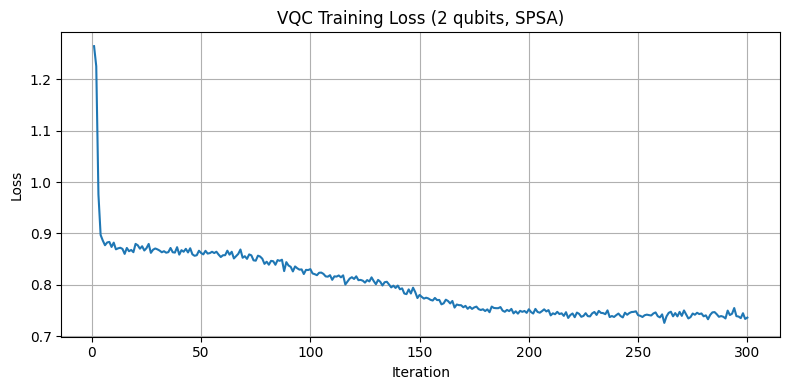

In [8]:
# --- Loss curve ---
if loss_history:
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(loss_history) + 1), loss_history, color="tab:blue")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(f"VQC Training Loss ({N_FEATURES} qubits, {OPTIMIZER_NAME})")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"vqc_loss_curve{FILE_SUFFIX}.png", dpi=150)
    plt.show()
else:
    print(f"Loss history not available for {OPTIMIZER_NAME} — skipping loss curve plot.")

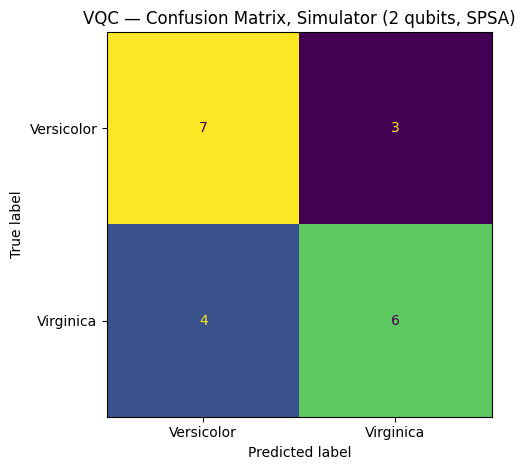

In [9]:
# --- Confusion matrix (simulator) ---
cm = confusion_matrix(y_test, y_pred_test_sim)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"VQC — Confusion Matrix, Simulator ({N_FEATURES} qubits, {OPTIMIZER_NAME})")
plt.tight_layout()
plt.savefig(f"vqc_confusion_matrix_sim{FILE_SUFFIX}.png", dpi=150)
plt.show()

In [ ]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.10
    xx, yy = np.meshgrid(np.arange(0, np.pi + h, h), np.arange(0, np.pi + h, h))
    grid   = np.c_[xx.ravel(), yy.ravel()]
    Z      = vqc.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                          cmap="coolwarm", edgecolors="k", s=40, label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="r", s=60, marker="^", label="Test")
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel("petal length (scaled × π)")
    plt.ylabel("petal width  (scaled × π)")
    plt.title(f"VQC — Decision Boundary (2 qubits, {OPTIMIZER_NAME})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"vqc_decision_boundary{FILE_SUFFIX}.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Save Results

In [11]:
results = {
    # --- Experiment metadata ---
    "model"              : "VQC",
    "n_features"         : N_FEATURES,
    "n_qubits"           : n_qubits,
    "feature_names"      : feature_names,
    "n_train"            : int(len(X_train)),
    "n_test"             : int(len(X_test)),
    "random_seed"        : RANDOM_SEED,
    # --- Circuit architecture ---
    "feature_map"        : "ZZFeatureMap",
    "feature_map_reps"   : 2,
    "ansatz"             : "RealAmplitudes",
    "ansatz_reps"        : 3,
    "n_parameters"       : int(ansatz.num_parameters),
    "optimizer"          : OPTIMIZER_NAME,
    "max_iter"           : MAX_ITER,
    # --- Timing ---
    "train_time_sim_s"   : float(train_time_sim),
    # --- Accuracy reference run ---
    "accuracy_test_sim"  : float(acc_test_sim),
    "accuracy_train_sim" : float(acc_train_sim),
    # --- Multi-seed stability ---
    "n_runs"             : N_RUNS,
    "init_seeds"         : INIT_SEEDS,
    "accuracy_test_runs" : [float(a) for a in acc_test_runs],
    "accuracy_test_mean" : acc_test_mean,
    "accuracy_test_std"  : acc_test_std,
    "accuracy_train_runs": [float(a) for a in acc_train_runs],
    "accuracy_train_mean": acc_train_mean,
    "accuracy_train_std" : acc_train_std,
    # --- Loss history (reference run, SPSA only) ---
    "loss_history"       : [float(l) for l in loss_history],
    # --- Predictions (reference run) ---
    "y_test"             : y_test.tolist(),
    "y_pred_test_sim"    : y_pred_test_sim.tolist(),
    # --- Real hardware (filled only if RUN_ON_REAL_HW=True) ---
    "real_hw_run"        : RUN_ON_REAL_HW,
    "backend_name"       : backend_name,
    "accuracy_test_real" : float(acc_test_real) if acc_test_real is not None else None,
    "y_pred_test_real"   : y_pred_test_real.tolist() if y_pred_test_real is not None else None,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
skip = {"loss_history", "y_test", "y_pred_test_sim", "y_pred_test_real", "accuracy_test_runs", "accuracy_train_runs"}
print(json.dumps({k: v for k, v in results.items() if k not in skip}, indent=2))

Results saved to vqc_results.json
{
  "model": "VQC",
  "n_features": 2,
  "n_qubits": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "feature_map": "ZZFeatureMap",
  "feature_map_reps": 2,
  "ansatz": "RealAmplitudes",
  "ansatz_reps": 3,
  "n_parameters": 8,
  "optimizer": "SPSA",
  "max_iter": 300,
  "train_time_sim_s": 219.35475362099896,
  "accuracy_test_sim": 0.65,
  "accuracy_train_sim": 0.775,
  "n_runs": 3,
  "init_seeds": [
    42,
    123,
    7
  ],
  "accuracy_test_mean": 0.6333333333333333,
  "accuracy_test_std": 0.09428090415820632,
  "accuracy_train_mean": 0.7208333333333332,
  "accuracy_train_std": 0.05034602488997736,
  "real_hw_run": false,
  "backend_name": null,
  "accuracy_test_real": null
}
